<a href="https://colab.research.google.com/github/ashabb-ipl/iplCapstoneForPredictiveAI/blob/main/AnomalyDetection2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Start

Synthetic training data saved to: anomaly_reports/synthetic_training_data.csv
Actual contamination rate: 0.0500

--- Model Evaluation Metrics ---
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
AUC-ROC:   1.0000

Confusion Matrix:
[[1425    0]
 [   0   75]]


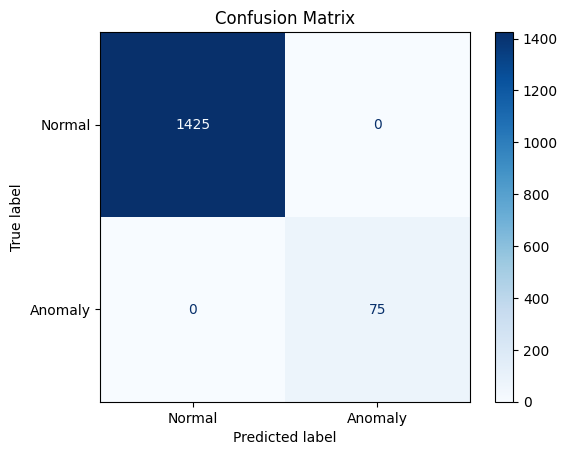

Detailed prediction report saved to: anomaly_reports/anomaly_detection_predictions.csv
Quality parameters report saved/appended to: anomaly_reports/anomaly_detection_quality_metrics.csv


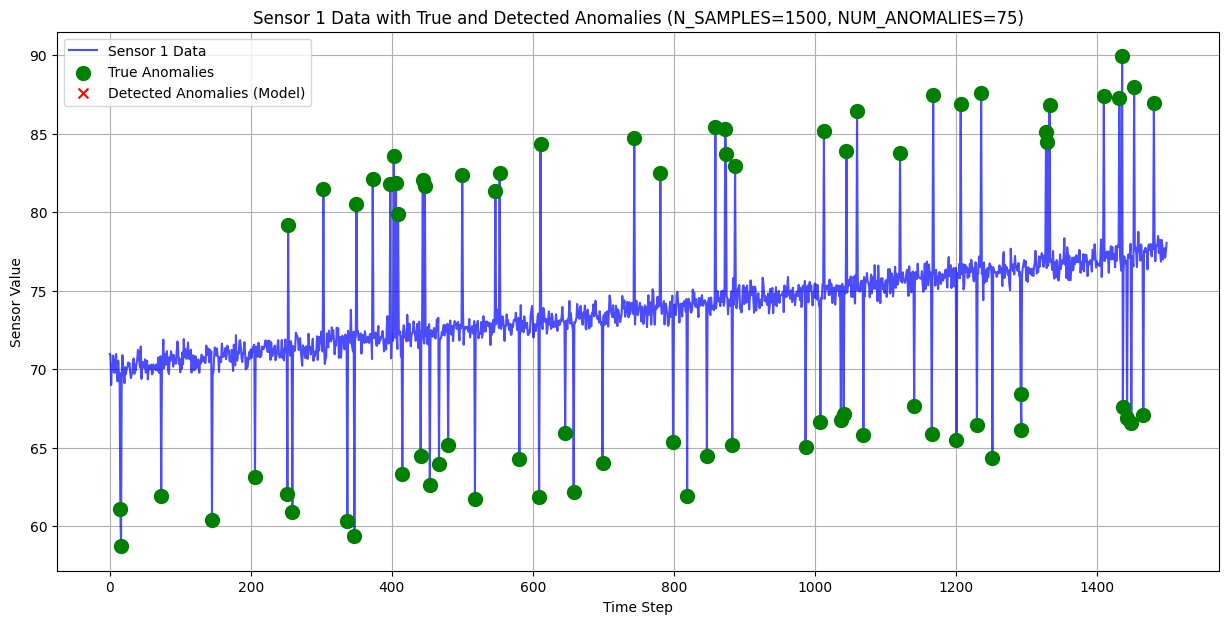

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import os
from datetime import datetime # To add a timestamp to the report

# --- Parameters for Synthetic Data Generation (Original Values) ---
N_SAMPLES = 1500  # Original number of samples
BASE_VALUE_1 = 70
BASE_VALUE_2 = 58
TREND_SLOPE_1 = 0.005
NOISE_LEVEL = 0.5
NUM_ANOMALIES = 75  # Original number of anomalies
ANOMALY_MAGNITUDE = 10

# --- Generate Synthetic Sensor 1 Data ---
time_steps = np.arange(N_SAMPLES)
sensor_1_data = BASE_VALUE_1 + (TREND_SLOPE_1 * time_steps) + \
                np.random.normal(0, NOISE_LEVEL, N_SAMPLES)

# --- Inject Anomalies into Sensor 1 ---
# Keep track of true anomaly indices for evaluation
num_anomalies_to_inject = min(NUM_ANOMALIES, N_SAMPLES)
true_anomaly_indices = np.random.choice(N_SAMPLES, num_anomalies_to_inject, replace=False)
true_anomaly_indices.sort() # Good for consistent tracking

for idx in true_anomaly_indices:
    if np.random.rand() > 0.5:
        sensor_1_data[idx] += ANOMALY_MAGNITUDE * np.random.uniform(0.8, 1.2) # Spike
    else:
        sensor_1_data[idx] -= ANOMALY_MAGNITUDE * np.random.uniform(0.8, 1.2) # Dip

# --- Prepare data for Isolation Forest ---
data_for_model = pd.DataFrame(sensor_1_data, columns=['Sensor1'])

# --- Save Training Data to CSV ---
output_dir = 'anomaly_reports'
os.makedirs(output_dir, exist_ok=True) # Ensure the directory exists
training_data_filename = os.path.join(output_dir, 'synthetic_training_data.csv')
data_for_model.to_csv(training_data_filename, index=False)
print(f"Synthetic training data saved to: {training_data_filename}")

# --- Isolation Forest Model ---
# Calculate contamination based on injected anomalies for more accurate evaluation
actual_contamination_rate = num_anomalies_to_inject / N_SAMPLES
print(f"Actual contamination rate: {actual_contamination_rate:.4f}")

# Initialize and train the Isolation Forest model
model = IsolationForest(contamination=actual_contamination_rate, random_state=42)
model.fit(data_for_model)

# Predict anomalies (-1 for outliers, 1 for inliers)
predictions = model.predict(data_for_model)
anomaly_scores = model.decision_function(data_for_model)

# --- Evaluation ---

# 1. Create true labels (ground truth)
y_true = np.zeros(N_SAMPLES, dtype=int)
y_true[true_anomaly_indices] = 1

# 2. Convert model predictions to match true labels (0 for normal, 1 for anomaly)
y_pred = np.where(predictions == -1, 1, 0)

print("\n--- Model Evaluation Metrics ---")

# Calculate metrics
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc_roc = roc_auc_score(y_true, -anomaly_scores) # Negate scores for AUC-ROC

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc_roc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Optionally, visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomaly"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# --- Create Detailed Prediction Report DataFrame ---
report_df = data_for_model.copy()
report_df['True_Anomaly'] = y_true
report_df['Predicted_Anomaly'] = y_pred
report_df['Anomaly_Score'] = anomaly_scores

# Determine if prediction was correct
report_df['Is_Correct_Prediction'] = (report_df['True_Anomaly'] == report_df['Predicted_Anomaly'])

# Determine the type of prediction (TP, FP, TN, FN)
def get_prediction_type(row):
    if row['True_Anomaly'] == 1 and row['Predicted_Anomaly'] == 1:
        return 'TP' # True Positive
    elif row['True_Anomaly'] == 0 and row['Predicted_Anomaly'] == 1:
        return 'FP' # False Positive
    elif row['True_Anomaly'] == 0 and row['Predicted_Anomaly'] == 0:
        return 'TN' # True Negative
    else: # row['True_Anomaly'] == 1 and row['Predicted_Anomaly'] == 0
        return 'FN' # False Negative

report_df['Prediction_Type'] = report_df.apply(get_prediction_type, axis=1)

# --- Save Detailed Prediction Report to CSV ---
prediction_report_filename = os.path.join(output_dir, 'anomaly_detection_predictions.csv')
report_df.to_csv(prediction_report_filename, index=False)
print(f"Detailed prediction report saved to: {prediction_report_filename}")

# --- Create and Save Quality Parameters Report to CSV ---
metrics_data = {
    'Timestamp': [datetime.now().strftime("%Y-%m-%d %H:%M:%S")],
    'N_SAMPLES': [N_SAMPLES],
    'NUM_ANOMALIES_INJECTED': [num_anomalies_to_inject],
    'Contamination_Rate_Used': [actual_contamination_rate],
    'Precision': [precision],
    'Recall': [recall],
    'F1_Score': [f1],
    'AUC_ROC': [auc_roc],
    'True_Positives': [cm[1, 1]], # cm[true, pred]
    'False_Positives': [cm[0, 1]],
    'True_Negatives': [cm[0, 0]],
    'False_Negatives': [cm[1, 0]],
    'Model_Parameters': [f"n_estimators={model.n_estimators}, max_samples={model.max_samples}, random_state={model.random_state}"]
}
metrics_df = pd.DataFrame(metrics_data)

metrics_report_filename = os.path.join(output_dir, 'anomaly_detection_quality_metrics.csv')

# Check if the file already exists to decide whether to write header
if not os.path.isfile(metrics_report_filename):
    metrics_df.to_csv(metrics_report_filename, index=False)
else:
    metrics_df.to_csv(metrics_report_filename, mode='a', header=False, index=False)

print(f"Quality parameters report saved/appended to: {metrics_report_filename}")

# --- Visualization (Optional, but highly recommended for anomaly detection) ---
plt.figure(figsize=(15, 7)) # Adjust figure size for larger dataset
plt.plot(data_for_model.index, data_for_model['Sensor1'], label='Sensor 1 Data', color='blue', alpha=0.7)

# Highlight true anomalies
plt.scatter(true_anomaly_indices, data_for_model.loc[true_anomaly_indices, 'Sensor1'],
            color='green', s=100, marker='o', label='True Anomalies', zorder=5)

# Highlight detected anomalies by the model
detected_anomaly_indices = data_for_model.index[predictions == -1]
plt.scatter(detected_anomaly_indices, data_for_model.loc[detected_anomaly_indices, 'Sensor1'],
            color='red', s=50, marker='x', label='Detected Anomalies (Model)', zorder=4)

plt.title(f'Sensor 1 Data with True and Detected Anomalies (N_SAMPLES={N_SAMPLES}, NUM_ANOMALIES={num_anomalies_to_inject})')
plt.xlabel('Time Step')
plt.ylabel('Sensor Value')
plt.legend()
plt.grid(True)
plt.show()

# --- Saving data to Google Drive (if uncommented and setup) ---
# from google.colab import drive
# drive.mount('/content/drive')
# output_drive_path = '/content/drive/MyDrive/my_colab_data/'
# os.makedirs(output_drive_path, exist_ok=True)
#
# # Save the training data to Drive
# drive_training_data_path = os.path.join(output_drive_path, 'synthetic_training_data.csv')
# data_for_model.to_csv(drive_training_data_path, index=False)
# print(f"Synthetic training data saved to Google Drive at: {drive_training_data_path}")
#
# # Save the prediction report to Drive
# drive_prediction_report_path = os.path.join(output_drive_path, 'anomaly_detection_predictions.csv')
# report_df.to_csv(drive_prediction_report_path, index=False)
# print(f"Detailed prediction report saved to Google Drive at: {drive_prediction_report_path}")
#
# # Save/append the quality metrics report to Drive
# drive_metrics_report_path = os.path.join(output_drive_path, 'anomaly_detection_quality_metrics.csv')
# if not os.path.isfile(drive_metrics_report_path):
#     metrics_df.to_csv(drive_metrics_report_path, index=False)
# else:
#     metrics_df.to_csv(drive_metrics_report_path, mode='a', header=False, index=False)
# print(f"Quality parameters report saved/appended to Google Drive at: {drive_metrics_report_path}")

Data saved to isolation_forest_training_data.csv
Shape of data for IsolationForest: (1500, 2)

First 5 rows of combined sensor data:
   Sensor_1_Value  Sensor_2_Value
0       69.592003       59.253844
1       71.065719       58.938746
2       61.786880       57.555013
3       69.727236       58.337277
4       70.221158       57.949283

Training IsolationForest model...
IsolationForest model training complete!

First 10 rows with anomaly scores and predictions:
   Sensor_1_Value  Sensor_2_Value  anomaly_score  is_anomaly
0       69.592003       59.253844       0.177645           1
1       71.065719       58.938746       0.230262           1
2       61.786880       57.555013       0.008619           1
3       69.727236       58.337277       0.226436           1
4       70.221158       57.949283       0.240246           1
5       69.599388       58.176993       0.219030           1
6       70.043368       57.588535       0.236833           1
7       70.235348       59.681320       0.15120

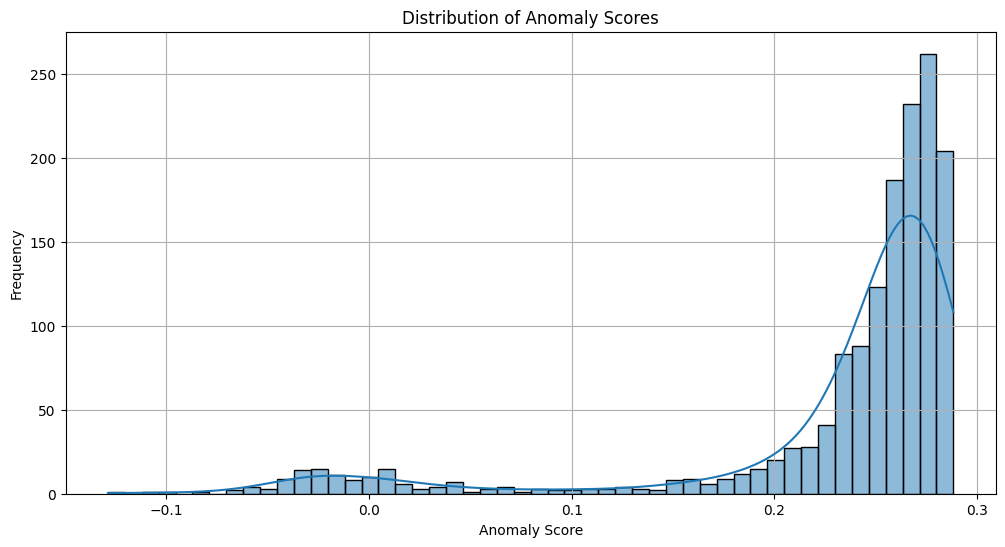

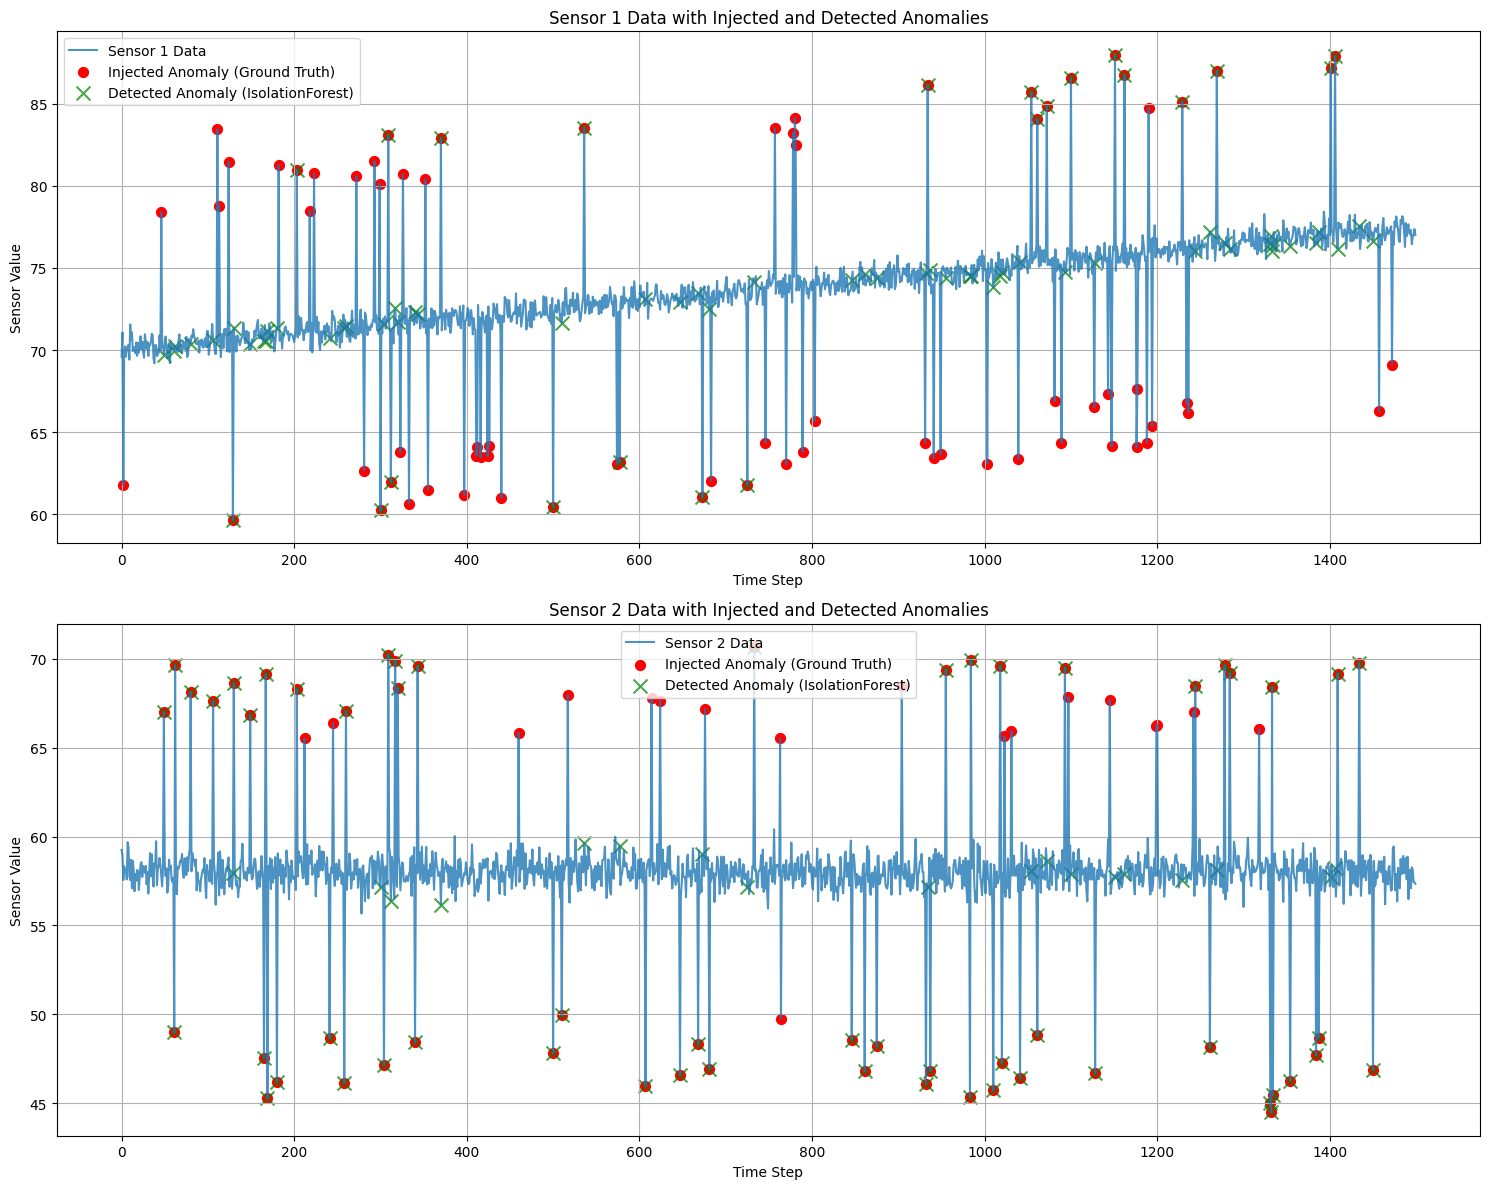

In [17]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming sensor_1_data and sensor_2_data are already defined from previous steps
# If not, you'd need to re-run the data generation code.

# 1. Combine sensor data into a DataFrame for IsolationForest
# IsolationForest expects a 2D array, where each row is a sample and each column is a feature.
# Here, our features are the values from Sensor 1 and Sensor 2 at each time step.
data_for_model = pd.DataFrame({
    'Sensor_1_Value': sensor_1_data,
    'Sensor_2_Value': sensor_2_data
})
# Save the DataFrame to a CSV file
data_for_model.to_csv('isolation_forest_training_data.csv', index=False)
print("Data saved to isolation_forest_training_data.csv")

print("Shape of data for IsolationForest:", data_for_model.shape)
print("\nFirst 5 rows of combined sensor data:")
print(data_for_model.head())

# 2. Initialize and Train the IsolationForest Model
# n_estimators: The number of base estimators (trees) in the ensemble. More trees generally lead to better performance but take longer.
# contamination: The proportion of outliers in the data set. This is a crucial parameter.
#                If you know roughly what percentage of your data is anomalous, you can set it.
#                If not, a common practice is to start with a small value (e.g., 0.01 to 0.1) or 'auto'.
#                For our synthetic data, we injected a known percentage of anomalies, so we can use that.
#                Let's assume we injected about 5% anomalies for demonstration.
# random_state: For reproducibility.
model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)

# Fit the model to our combined sensor data
# The fit method trains the model to understand the 'normal' patterns in the data.
print("\nTraining IsolationForest model...")
model.fit(data_for_model) # Model is fit on 'Sensor_1_Value' and 'Sensor_2_Value'
print("IsolationForest model training complete!")

# 3. Generate Anomaly Scores
# The decision_function method computes the anomaly score for each sample.
# Lower scores indicate a higher likelihood of being an anomaly.
data_for_model['anomaly_score'] = model.decision_function(data_for_model[['Sensor_1_Value', 'Sensor_2_Value']]) # IMPORTANT: Only pass original features

# 4. Predict Anomalies
# The predict method returns -1 for outliers and 1 for inliers.
# This classification is based on the 'contamination' parameter set during initialization.
data_for_model['is_anomaly'] = model.predict(data_for_model[['Sensor_1_Value', 'Sensor_2_Value']]) # IMPORTANT: Only pass original features

print("\nFirst 10 rows with anomaly scores and predictions:")
print(data_for_model.head(10))

# Let's see how many anomalies were detected
num_detected_anomalies = data_for_model[data_for_model['is_anomaly'] == -1].shape[0]
print(f"\nNumber of detected anomalies by IsolationForest: {num_detected_anomalies}")

# Quick visualization of anomaly scores
plt.figure(figsize=(12, 6))
sns.histplot(data_for_model['anomaly_score'], bins=50, kde=True)
plt.title('Distribution of Anomaly Scores')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# You can also visualize the detected anomalies on our original plots
# Let's add the detected anomalies to the original plot for comparison

# Get the indices of the detected anomalies
detected_anomaly_indices = data_for_model[data_for_model['is_anomaly'] == -1].index

plt.figure(figsize=(15, 12))

# Plot for Sensor 1
plt.subplot(2, 1, 1)
plt.plot(sensor_1_data, label='Sensor 1 Data', alpha=0.8)
plt.scatter(injected_anomaly_indices_1, sensor_1_data[injected_anomaly_indices_1], color='red', s=50, label='Injected Anomaly (Ground Truth)')
plt.scatter(detected_anomaly_indices, sensor_1_data[detected_anomaly_indices], color='green', marker='x', s=100, label='Detected Anomaly (IsolationForest)', alpha=0.7)
plt.title('Sensor 1 Data with Injected and Detected Anomalies')
plt.xlabel('Time Step')
plt.ylabel('Sensor Value')
plt.grid(True)
plt.legend()

# Plot for Sensor 2
plt.subplot(2, 1, 2)
plt.plot(sensor_2_data, label='Sensor 2 Data', alpha=0.8)
plt.scatter(injected_anomaly_indices_2, sensor_2_data[injected_anomaly_indices_2], color='red', s=50, label='Injected Anomaly (Ground Truth)')
plt.scatter(detected_anomaly_indices, sensor_2_data[detected_anomaly_indices], color='green', marker='x', s=100, label='Detected Anomaly (IsolationForest)', alpha=0.7)
plt.title('Sensor 2 Data with Injected and Detected Anomalies')
plt.xlabel('Time Step')
plt.ylabel('Sensor Value')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()